In [1]:
from pathlib import Path
import kagglehub

dataset_id = "zygmunt/goodbooks-10k"
target_dir = Path("data")

target_dir.mkdir(exist_ok=True)

files_in_target = list(target_dir.iterdir())

if files_in_target:
    print("Данные уже есть в папке 'data', повторная загрузка не требуется.")
else:
    kagglehub.dataset_download(
        dataset_id,
        output_dir=str(target_dir)
    )

    print("Датасет успешно загружен в папку 'data'.")

path = target_dir.resolve()

print("Path to dataset files:", path)

Данные уже есть в папке 'data', повторная загрузка не требуется.
Path to dataset files: C:\YandexDisk\mystuff\MIFI\rec_sys_home\data


c:\YandexDisk\mystuff\MIFI\rec_sys_home\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import pandas as pd

df_book_tags = pd.read_csv(target_dir/'book_tags.csv')
df_books = pd.read_csv(target_dir/'books.csv')
df_ratings = pd.read_csv(target_dir/'ratings.csv')
df_tags  = pd.read_csv(target_dir/'tags.csv')
df_to_read = pd.read_csv(target_dir/'to_read.csv')

In [3]:
df_book_tags.head()

,goodreads_book_id,tag_id,count
0,1,30574,167697
1,1,11305,37174
2,1,11557,34173
3,1,8717,12986
4,1,33114,12716


In [4]:
df_books.head()

,id,book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,...,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,...,4780653,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...
1,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,...,4602479,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...
2,3,41865,41865,3212258,226,316015849,9.780316e+12,Stephenie Meyer,2005.0,Twilight,...,3866839,3916824,95009,456191,436802,793319,875073,1355439,https://images.gr-assets.com/books/1361039443m...,https://images.gr-assets.com/books/1361039443s...
3,4,2657,2657,3275794,487,61120081,9.780061e+12,Harper Lee,1960.0,To Kill a Mockingbird,...,3198671,3340896,72586,60427,117415,446835,1001952,1714267,https://images.gr-assets.com/books/1361975680m...,https://images.gr-assets.com/books/1361975680s...
4,5,4671,4671,245494,1356,743273567,9.780743e+12,F. Scott Fitzgerald,1925.0,The Great Gatsby,...,2683664,2773745,51992,86236,197621,606158,936012,947718,https://images.gr-assets.com/books/1490528560m...,https://images.gr-assets.com/books/1490528560s...


In [5]:
df_ratings.head()

,book_id,user_id,rating
0,1,314,5
1,1,439,3
2,1,588,5
3,1,1169,4
4,1,1185,4


In [6]:
df_tags.head()

,tag_id,tag_name
0,0,-
1,1,--1-
2,2,--10-
3,3,--12-
4,4,--122-


In [7]:
df_to_read.head()

,user_id,book_id
0,1,112
1,1,235
2,1,533
3,1,1198
4,1,1874


Распределение оценок. Есть ли смещение в сторону высоких оценок?

<Axes: xlabel='rating'>

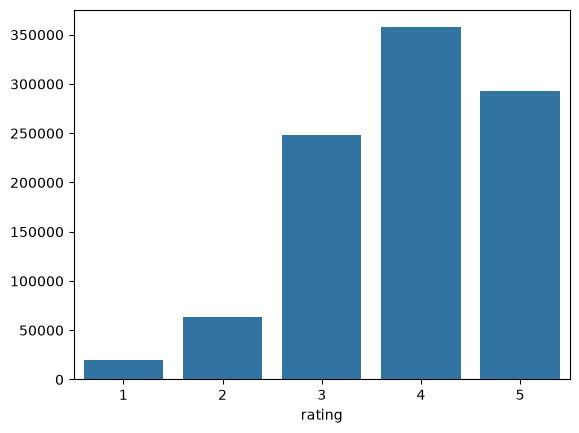

In [8]:
import seaborn as sns
counts = df_ratings['rating'].value_counts().sort_index()
sns.barplot(x=counts.index, y=counts.values, errorbar=None)

Анализ активности пользователей. Постройте график «Взаимоотношение количества пользователей и количества оценок». Выявите активных пользователей и пользователей с малым количеством взаимодействий (проблема холодного старта).

<Figure size 1600x800 with 0 Axes>

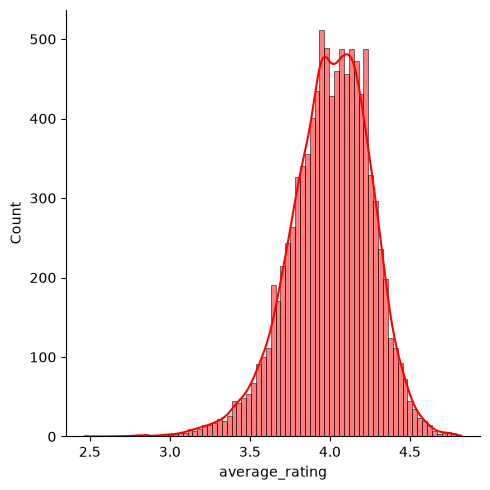

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(16,8))
sns.displot(x=df_books['average_rating'], kde=True, color='r')

In [10]:
df_ratings

,book_id,user_id,rating
0,1,314,5
1,1,439,3
2,1,588,5
3,1,1169,4
4,1,1185,4
...,...,...,...
981751,10000,48386,5
981752,10000,49007,4
981753,10000,49383,5
981754,10000,50124,5


In [25]:
rating_per_user=df_ratings.groupby(by='user_id', as_index=False).agg(ratings_count = ('rating','count'))
ratings_count_for_user = rating_per_user.groupby(by='ratings_count', as_index=False).agg(ratings_count_for_user =('user_id','count') )
ratings_count_for_user['ratings_count'].quantile(0.9)

np.float64(179.3)

In [24]:
ratings_count_for_user

,ratings_count_for_user
ratings_count,
2,8302
3,5436
4,3976
5,3212
6,2471
...,...
195,5
196,7
197,3


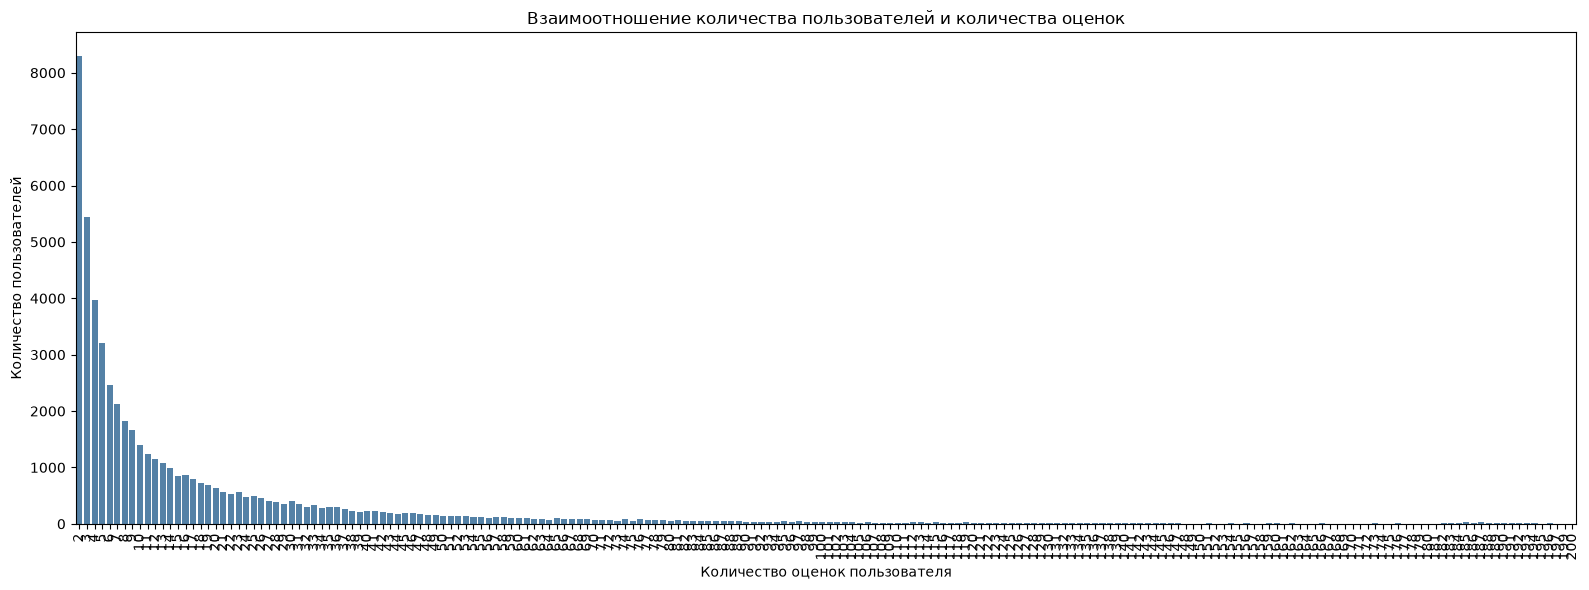

In [11]:
user_activity = pd.pivot_table(
    data=df_ratings,
    index='user_id',
    aggfunc={'rating': 'count'}
).rename(columns={'rating': 'ratings_count'})

activity_distribution = pd.pivot_table(
    data=user_activity.reset_index(),
    index='ratings_count',
    aggfunc={'user_id': 'count'}
).rename(columns={'user_id': 'users_count'})

plt.figure(figsize=(16, 6))
sns.barplot(
    x=activity_distribution.index,
    y=activity_distribution['users_count'],
    color='steelblue',
    errorbar=None
)
plt.xlabel('Количество оценок пользователя')
plt.ylabel('Количество пользователей')
plt.title('Взаимоотношение количества пользователей и количества оценок')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [12]:
cold_users = user_activity.loc[user_activity['ratings_count']<=5,'ratings_count']
active_threshold = int(activity_distribution.index.to_series().quantile(0.9))
active_users = user_activity.loc[user_activity['ratings_count']>=active_threshold,'ratings_count']

print(f'Всего пользователей: {len(user_activity):,}')
print(f'С 1–5 оценками: {len(cold_users):,} '
      f'({len(cold_users) / len(user_activity):.1%})')
print(f'Активных: {len(active_users):,} '
      f'(порог — {active_threshold:g} оценок)')

display(active_users.head(10).rename('Количество оценок').to_frame())
display(cold_users.head(10).rename('Количество оценок').to_frame())

Всего пользователей: 53,424
С 1–5 оценками: 20,926 (39.2%)
Активных: 238 (порог — 179 оценок)


,Количество оценок
user_id,
314,181
588,186
951,188
1169,187
1185,190
1952,189
2077,180
2171,184
2276,185


,Количество оценок
user_id,
1,3
2,3
3,2
4,3
5,5
6,2
8,3
12,2
13,2


**Анализ популярности книг. Постройте график «Количество книг vs количество оценок». Выявите популярные книги и «длинный хвост».**

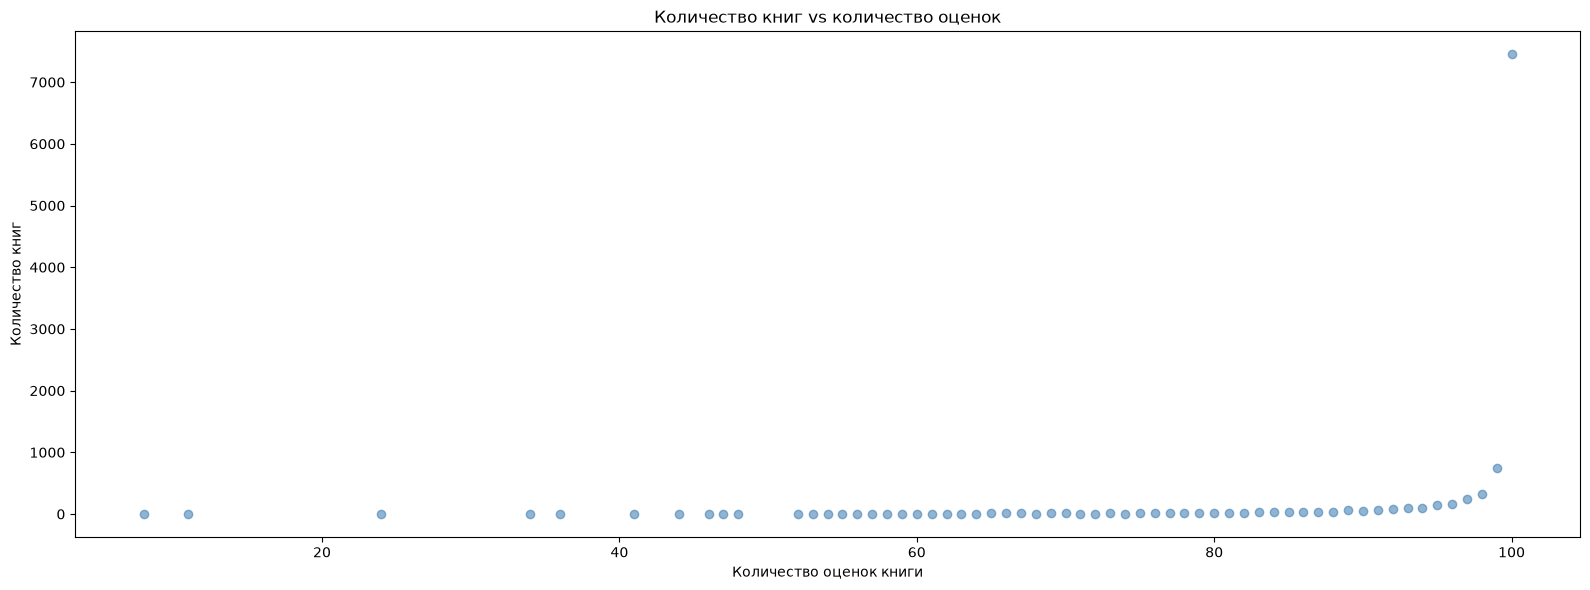

In [13]:
book_activity = pd.pivot_table(
    data=df_ratings,
    index='book_id',
    aggfunc={'rating': 'count'}
).rename(columns={'rating': 'ratings_count'})

popularity_distribution = pd.pivot_table(
    data=book_activity.reset_index(),
    index='ratings_count',
    aggfunc={'book_id': 'count'}
).rename(columns={'book_id': 'books_count'})

plt.figure(figsize=(16, 6))
plt.scatter(
    popularity_distribution.index,
    popularity_distribution['books_count'],
    color='steelblue',
    alpha=0.6
)
plt.xlabel('Количество оценок книги')
plt.ylabel('Количество книг')
plt.title('Количество книг vs количество оценок')
plt.tight_layout()
plt.show()

In [14]:
popular_threshold = book_activity['ratings_count'].quantile(0.9)

popular_books = book_activity[
    book_activity['ratings_count'] >= popular_threshold
].sort_values('ratings_count', ascending=False)

long_tail_books = book_activity[
    book_activity['ratings_count'] <= 10
].sort_values('ratings_count')

print(f'Популярных книг: {len(popular_books):,}')
print(f'Порог популярности: {popular_threshold:g} оценок')
print(f'Книг в длинном хвосте: {len(long_tail_books):,}')
print(f'Доля длинного хвоста: {len(long_tail_books) / len(book_activity):.1%}')

display(
    popular_books.head(10)
    .reset_index()
    .merge(df_books[['book_id', 'title']], on='book_id', how='left')
    [['book_id', 'title', 'ratings_count']]
)

Популярных книг: 7,456
Порог популярности: 100 оценок
Книг в длинном хвосте: 1
Доля длинного хвоста: 0.0%


,book_id,title,ratings_count
0,1,Harry Potter and the Half-Blood Prince (Harry ...,100
1,2,Harry Potter and the Order of the Phoenix (Har...,100
2,3,Harry Potter and the Sorcerer's Stone (Harry P...,100
3,4,NaN,100
4,5,Harry Potter and the Prisoner of Azkaban (Harr...,100
5,6,Harry Potter and the Goblet of Fire (Harry Pot...,100
6,7,NaN,100
7,8,"Harry Potter Boxed Set, Books 1-5 (Harry Potte...",100
8,9,NaN,100
9,10,"Harry Potter Collection (Harry Potter, #1-6)",100


In [15]:
df_book_tags_merged = pd.merge(left=df_book_tags,right=df_tags, on='tag_id')
top_tags = pd.pivot_table(data=df_book_tags_merged, index='tag_name', aggfunc={'tag_id':'count'}).rename(columns={'tag_id': 'tag_id_count'}).sort_values(by='tag_id_count', ascending=False)[0:15]


In [16]:
df_book_tags_merged

,goodreads_book_id,tag_id,count,tag_name
0,1,30574,167697,to-read
1,1,11305,37174,fantasy
2,1,11557,34173,favorites
3,1,8717,12986,currently-reading
4,1,33114,12716,young-adult
...,...,...,...,...
999907,33288638,21303,7,neighbors
999908,33288638,17271,7,kindleunlimited
999909,33288638,1126,7,5-star-reads
999910,33288638,11478,7,fave-author


In [17]:
top_tags

,tag_id_count
tag_name,
to-read,9983
favorites,9881
owned,9858
books-i-own,9799
currently-reading,9776
library,9415
owned-books,9221
fiction,9097
to-buy,8692


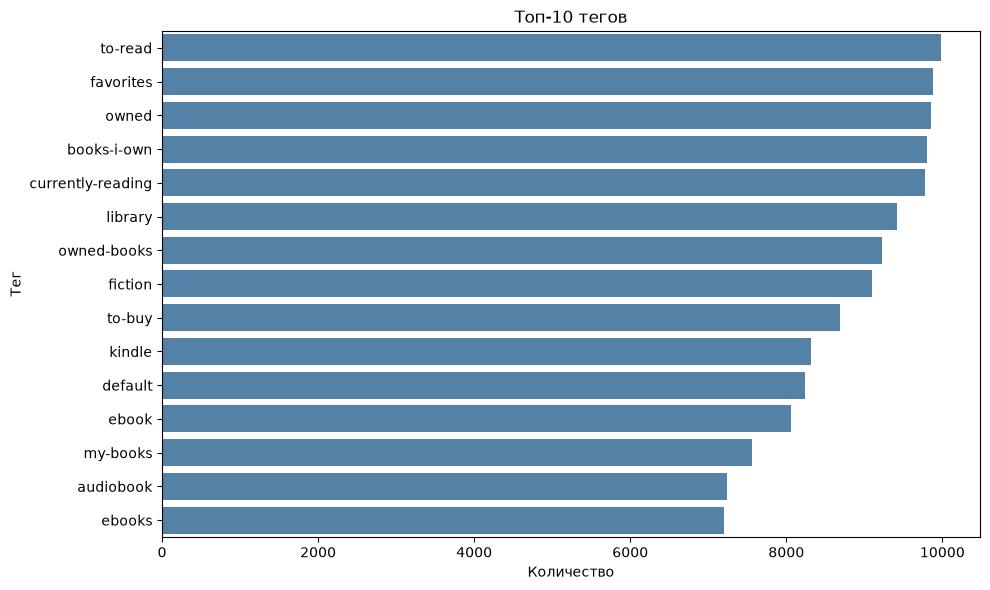

In [18]:

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_tags.reset_index(),
    x='tag_id_count',
    y='tag_name',
    color='steelblue'
)
plt.xlabel('Количество')
plt.ylabel('Тег')
plt.title('Топ-10 тегов')
plt.tight_layout()
plt.show()

In [19]:
df_book_tags.sort_values(by='count', ascending=False)

,goodreads_book_id,tag_id,count
8400,865,30574,596234
614494,2429135,30574,586235
911994,18143977,30574,505884
200,3,30574,496107
167200,24280,30574,488469
...,...,...,...
922053,18607805,17246,-1
922054,18607805,6552,-1
922055,18607805,2272,-1
922052,18607805,21619,-1


In [20]:
df_tags

,tag_id,tag_name
0,0,-
1,1,--1-
2,2,--10-
3,3,--12-
4,4,--122-
...,...,...
34247,34247,Ｃhildrens
34248,34248,Ｆａｖｏｒｉｔｅｓ
34249,34249,Ｍａｎｇａ
34250,34250,ＳＥＲＩＥＳ


Неперсонализированная модель: реализуйте алгоритм, возвращающий Top-N самых популярных книг (по среднему рейтингу с порогом минимального количества оценок).

In [27]:
df_books.columns

Index(['id', 'book_id', 'best_book_id', 'work_id', 'books_count', 'isbn',
       'isbn13', 'authors', 'original_publication_year', 'original_title',
       'title', 'language_code', 'average_rating', 'ratings_count',
       'work_ratings_count', 'work_text_reviews_count', 'ratings_1',
       'ratings_2', 'ratings_3', 'ratings_4', 'ratings_5', 'image_url',
       'small_image_url'],
      dtype='object')

In [49]:
def recomemnd_by_top_based(df_books:pd.DataFrame, ratings_trashhold:int, top_n:int) -> pd.DataFrame:
    df_books_trashhold = df_books.loc[df_books['ratings_count']>ratings_trashhold].copy()
    print(df_books_trashhold.columns)
    recommendations = df_books_trashhold.sort_values(by=['average_rating','ratings_count'], ascending=[False, False])[:top_n]
    return recommendations[['isbn','book_id','original_title','authors','average_rating','ratings_count']]

In [50]:
recomemnd_by_top_based(df_books = df_books, ratings_trashhold=10,top_n=10)

Index(['id', 'book_id', 'best_book_id', 'work_id', 'books_count', 'isbn',
       'isbn13', 'authors', 'original_publication_year', 'original_title',
       'title', 'language_code', 'average_rating', 'ratings_count',
       'work_ratings_count', 'work_text_reviews_count', 'ratings_1',
       'ratings_2', 'ratings_3', 'ratings_4', 'ratings_5', 'image_url',
       'small_image_url'],
      dtype='object')


,isbn,book_id,original_title,authors,average_rating,ratings_count
3627,740748475,24812,The Complete Calvin and Hobbes,Bill Watterson,4.82,28900
861,765326361,17332218,Words of Radiance,Brandon Sanderson,4.77,73572
3274,439682584,8,NaN,"J.K. Rowling, Mary GrandPré",4.77,33220
8853,842339523,95602,Mark of the Lion Trilogy,Francine Rivers,4.76,9081
7946,1433502410,5031805,NaN,"Anonymous, Lane T. Dennis, Wayne A. Grudem",4.76,8953
4482,836221362,24814,It's a Magical World: A Calvin and Hobbes Coll...,Bill Watterson,4.75,22351
421,545044251,862041,Complete Harry Potter Boxed Set,J.K. Rowling,4.74,190050
6360,836213122,70489,There's Treasure Everywhere: A Calvin and Hobb...,Bill Watterson,4.74,16766
3752,439827604,10,"Harry Potter Collection (Harry Potter, #1-6)",J.K. Rowling,4.73,24618
6589,751507954,59715,The Authoritative Calvin and Hobbes,Bill Watterson,4.73,16087


Контентная модель:
Объедините данные о книгах с их тегами. Для каждой книги создайте текстовый «профиль» из названия (original_title) и списка тегов.
Векторизуйте эти профили с помощью TF-IDF.
Реализуйте функцию get_similar_books(book_id, N=5), которая находит N самых похожих книг по косинусной мере близости между их TF-IDF-векторами.

In [51]:
import numpy as np
import pandas as pd

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import CountVectorizer

In [52]:
df_books.isnull().sum()

id                              0
book_id                         0
best_book_id                    0
work_id                         0
books_count                     0
isbn                          700
isbn13                        585
authors                         0
original_publication_year      21
original_title                585
title                           0
language_code                1084
average_rating                  0
ratings_count                   0
work_ratings_count              0
work_text_reviews_count         0
ratings_1                       0
ratings_2                       0
ratings_3                       0
ratings_4                       0
ratings_5                       0
image_url                       0
small_image_url                 0
dtype: int64

In [53]:
df_book_tags

,goodreads_book_id,tag_id,count
0,1,30574,167697
1,1,11305,37174
2,1,11557,34173
3,1,8717,12986
4,1,33114,12716
...,...,...,...
999907,33288638,21303,7
999908,33288638,17271,7
999909,33288638,1126,7
999910,33288638,11478,7


In [54]:
df_tags

,tag_id,tag_name
0,0,-
1,1,--1-
2,2,--10-
3,3,--12-
4,4,--122-
...,...,...
34247,34247,Ｃhildrens
34248,34248,Ｆａｖｏｒｉｔｅｓ
34249,34249,Ｍａｎｇａ
34250,34250,ＳＥＲＩＥＳ


In [59]:
book_tags_named = df_book_tags.merge(
    df_tags,
    on="tag_id",
    how="left"
)
book_tags_named


,goodreads_book_id,tag_id,count,tag_name
0,1,30574,167697,to-read
1,1,11305,37174,fantasy
2,1,11557,34173,favorites
3,1,8717,12986,currently-reading
4,1,33114,12716,young-adult
...,...,...,...,...
999907,33288638,21303,7,neighbors
999908,33288638,17271,7,kindleunlimited
999909,33288638,1126,7,5-star-reads
999910,33288638,11478,7,fave-author


In [79]:
book_tags_named_agregated = book_tags_named.groupby(by='goodreads_book_id').agg(tags_total = ('tag_name', lambda x:' '.join(x)))
df_for_rec=df_books[['book_id','original_title']].merge(book_tags_named_agregated, how='left', left_on='book_id' , right_on='goodreads_book_id')
df_for_rec['tags_total'] = df_for_rec['original_title']+' '+df_for_rec['tags_total']

In [80]:
books_and_tags=df_for_rec[['book_id','tags_total']]

In [81]:
books_and_tags

,book_id,tags_total
0,2767052,The Hunger Games favorites currently-reading y...
1,3,Harry Potter and the Philosopher's Stone to-re...
2,41865,Twilight young-adult fantasy favorites vampire...
3,2657,To Kill a Mockingbird classics favorites to-re...
4,4671,The Great Gatsby classics favorites fiction cl...
...,...,...
9995,7130616,Bayou Moon to-read urban-fantasy fantasy roman...
9996,208324,Means of Ascent to-read biography history pol...
9997,77431,The Mauritius Command to-read historical-ficti...
9998,8565083,Cinderella Ate My Daughter: Dispatches from th...


In [87]:
books_and_tags = books_and_tags.fillna(' ')

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=20_000
)

tfidf_matrix = tfidf.fit_transform(
    books_and_tags["tags_total"]
)



In [89]:
print(tfidf_matrix.shape)

(10000, 20000)


In [90]:
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
cosine_sim

array([[1.        , 0.31788548, 0.35367842, ..., 0.08510742, 0.14017692,
        0.03395422],
       [0.31788548, 1.        , 0.32234848, ..., 0.08336438, 0.14565193,
        0.04322539],
       [0.35367842, 0.32234848, 1.        , ..., 0.0595077 , 0.08445822,
        0.02876254],
       ...,
       [0.08510742, 0.08336438, 0.0595077 , ..., 1.        , 0.05355831,
        0.12451616],
       [0.14017692, 0.14565193, 0.08445822, ..., 0.05355831, 1.        ,
        0.10846615],
       [0.03395422, 0.04322539, 0.02876254, ..., 0.12451616, 0.10846615,
        1.        ]], shape=(10000, 10000))

In [91]:
books_title = df_books[['book_id', 'title']]

titles = books_title['title']
indices = pd.Series(books_title.index, index = books_title['title']) #converting all titles into a Series

#Function that gets book recommendations based on the cosine similarity score of book titles
def book_recommendations(title, n):
    idx = indices[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key = lambda x:x[1], reverse = True)
    sim_scores = sim_scores[1:n+1]
    book_indices = [i[0] for i in sim_scores]
    return titles.iloc[book_indices]

In [92]:
#Recommend n books for a book having index 1
book_index = 10
n = 20

print(books_title['title'][book_index])
book_recommendations(books_title.title[book_index],n)

The Kite Runner


66             A Thousand Splendid Suns
358            And the Mountains Echoed
27                    Lord of the Flies
7                The Catcher in the Rye
4                      The Great Gatsby
594                    A Separate Peace
3                 To Kill a Mockingbird
89                        The Outsiders
46                       The Book Thief
416                 The Thirteenth Tale
4490     The Pearl That Broke Its Shell
31                      Of Mice and Men
866                 The History of Love
128     One Flew Over the Cuckoo's Nest
9                   Pride and Prejudice
270                Flowers for Algernon
264            A Tree Grows in Brooklyn
556                 The Virgin Suicides
32                  Memoirs of a Geisha
82                 A Tale of Two Cities
Name: title, dtype: object